In [1]:
%load_ext autoreload
%autoreload 2
from trees.experiment import Experiment
from trees.topk import *
from trees.causal_tree import *
from trees.causal_forest import *

# D contains 10Κ rows

1. [Prediction Error] We observe the superiority of causal forest as an estimator as the prediction error is much better than in causal trees.
2. [False Estimation] Adding $P$ to $S_i$ does not alter the treatment effect  $\tau(R_i) = \tau(S_i)$.
3. [Overlap] The overlap is minimal in all variations of top-$K$ selection algorithms. ConstainedJ requires that the maximum pairwise overlap of two candidate $S_i$ and $S_j$ is less than 0.5.
ConstrainedT minimizes the overlap and will therefore achieve zero overlap.
Level based approaches have zero overlap by design.
4. [Depth] There seems to be an 'agreement' that the best splits are not at the bottom of the tree, but in the middle.
This is also where the most nodes exist.
5. [Features] It is interesting to see that CF uses less features than CT, which is desired for less complex queries and is completely unnecessary in our data (only two features impact HTE).
6. [Total Options] CT and CF generate the same amount of nodes. However, it makes sense that CT on P has less as it is trained on a smaller subset of D.
7. [Invalid Options] We observe that almost half of the nodes are invalid, except from CT on P where all nodes are valid.
8. [Online Execution Time] This measures the time required to generate valid subgroups. Training CT on P needs more time, while the rest (pretrained) only need half time to find valid subgroups. 
9. [TopK Execution Time] Measures the time required to find the top-$K$ subgroups. Only weighted and constrainedT cost some computation time.

  0%|          | 0/1 [00:00<?, ?it/s]

-------------------- New data --------------------
Generating data {'n': 10000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 2, 'override_p_with_2': False}
[Hybrid] CT - Offline time: 0.1s
[Online] CT - Offline time: 0.0s
[Hybrid] CF - Offline time: 7.95s
---------- Condition 1 out of 10 ----------
Generating random condition {'min_s': 0.3, 'max_s': 0.95, 'features_in_P': 'all', 'print_condition': True}
User condition: feature_9 <= 1.162 Selectivity: 0.8775
[Hybrid] CT running
Total subgroups: 314 Valid subgroups: 310
Filtered due to min rows: 4
Filtered due to not being subsets: 0
Filtering Time: 0.03
[Hybrid] CT - Online time: 0.03s
ConstrainedJ - get topK in 0.01s - {'k': 5}
ConstrainedT - get topK in 0.03s - {'k': 5}
Weighted - get topK in 0.02s - {'k': 5}
Random - get topK in 0.0s - {'k': 5}
LevelBased - get topK in 0.0s - {'k': 5}
LastLevel - get topK in 0.0s - {'k': 5}
[Online] CT running
Subgroups: 264
[Online] CT - Online time: 0.08s
ConstrainedJ - get topK in 0.0s - {'k': 5}
Con

100%|██████████| 1/1 [00:10<00:00, 10.80s/it]

LastLevel - get topK in 0.0s - {'k': 5}
[Hybrid] CF running
Total subgroups: 302 Valid subgroups: 302
Filtered due to min rows: 0
Filtered due to not being subsets: 0
Filtering Time: 0.03
[Hybrid] CF - Online time: 0.03s
ConstrainedJ - get topK in 0.01s - {'k': 5}
ConstrainedT - get topK in 0.02s - {'k': 5}
Weighted - get topK in 0.02s - {'k': 5}
Random - get topK in 0.0s - {'k': 5}
LevelBased - get topK in 0.0s - {'k': 5}
LastLevel - get topK in 0.0s - {'k': 5}
Finished 1 data iterations with 10 user interactions
data params {'n': [10000], 'p': [10], 'sigma': [3.0], 'seed': [42], 'mode': [2], 'override_p_with_2': [False]}
condition params {'min_s': [0.3], 'max_s': [0.95], 'features_in_P': ['all'], 'print_condition': [True]}
topK params {'k': [5]}


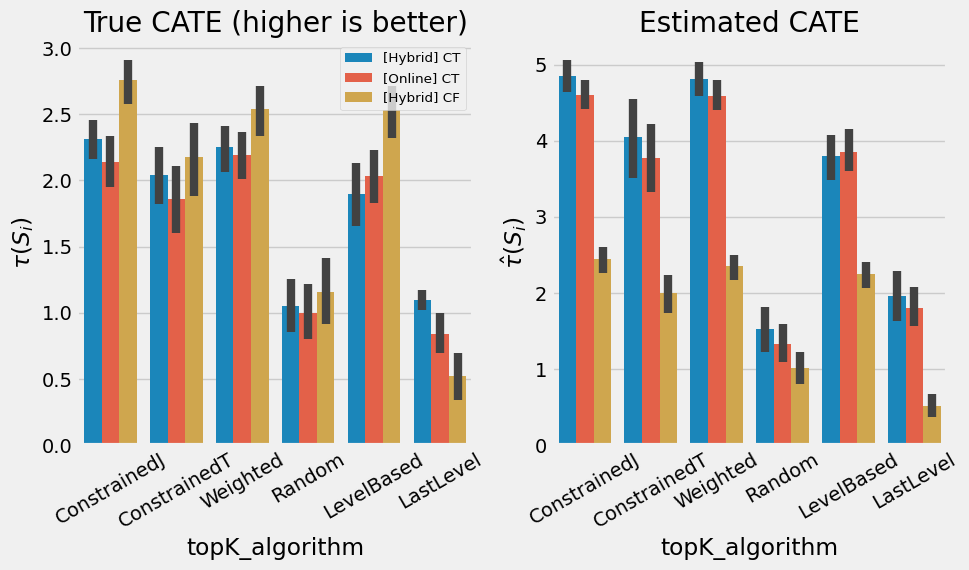

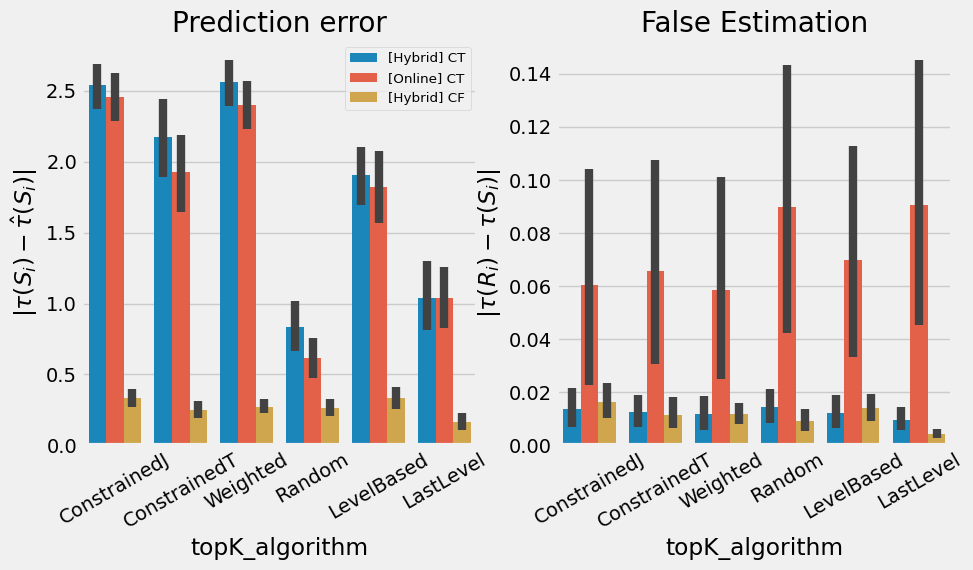

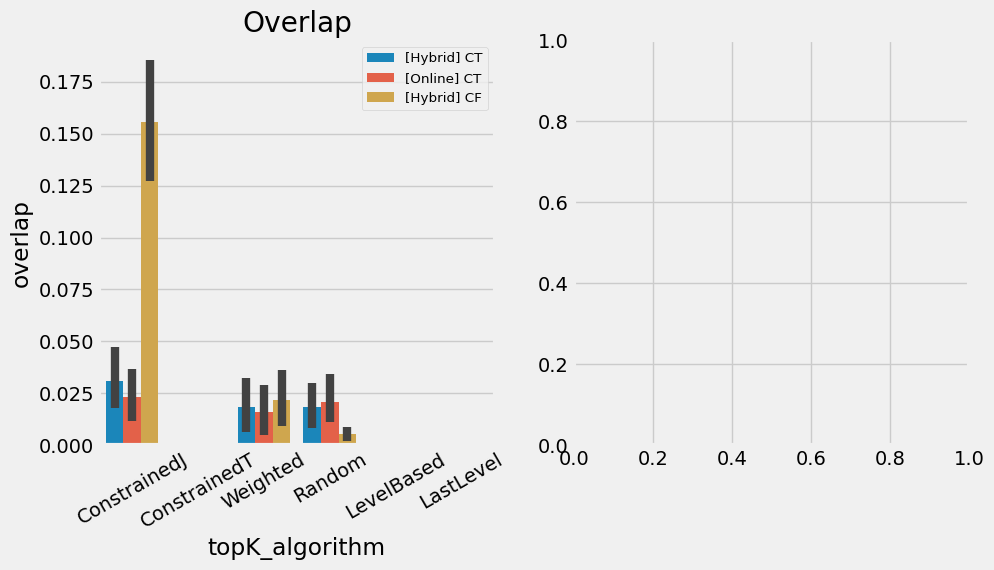

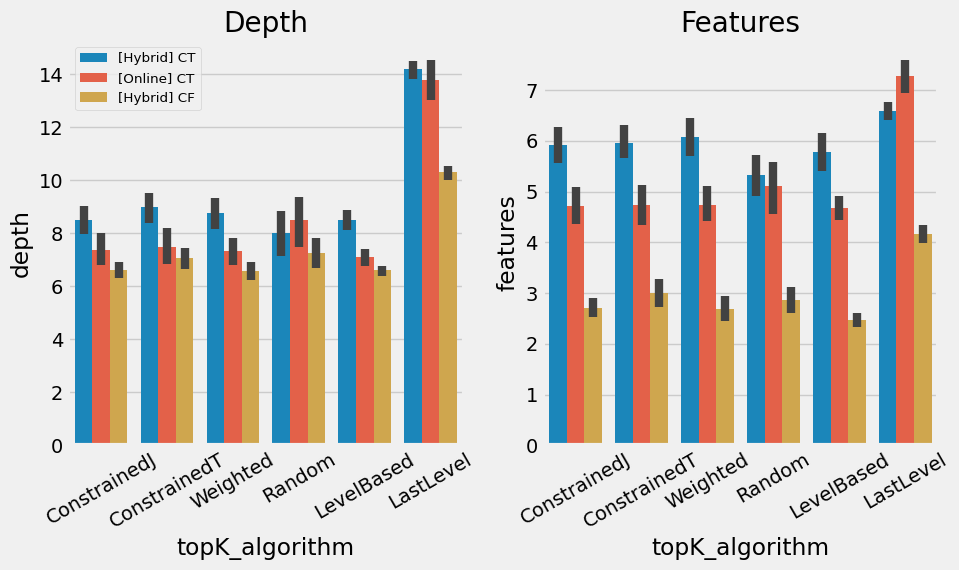

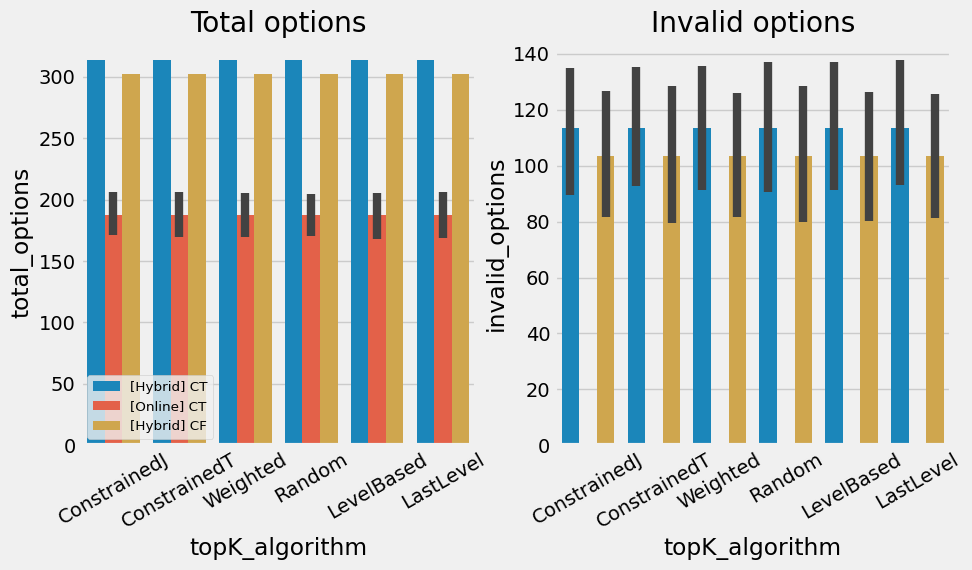

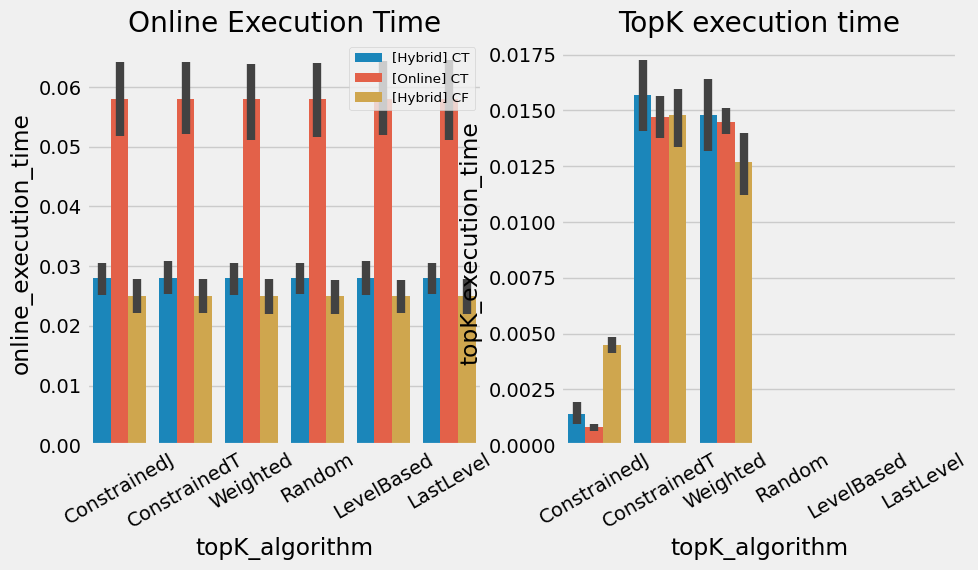

In [3]:
Experiment("topK_algorithm", data_iterations=1, user_iterations=10, algorithms=[CT(), CTP(), CFT()], scanners=all, save_csv=True)

# 100K

  0%|          | 0/1 [00:00<?, ?it/s]

-------------------- New data --------------------
Generating data {'n': 100000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 2, 'override_p_with_2': False}
[Hybrid] CT - Offline time: 1.78s
[Online] CT - Offline time: 0.0s
[Hybrid] CF - Offline time: 113.22s
---------- Condition 1 out of 10 ----------
Generating random condition {'min_s': 0.3, 'max_s': 0.95, 'features_in_P': 'all', 'print_condition': True}
User condition: feature_4 > -0.642 AND feature_0 > -1.973 Selectivity: 0.72112
[Hybrid] CT running
Total subgroups: 3050 Valid subgroups: 2416
Filtered due to min rows: 170
Filtered due to not being subsets: 464
Filtering Time: 0.77
[Hybrid] CT - Online time: 0.77s
ConstrainedJ - get topK in 0.02s - {'k': 5}
ConstrainedT - get topK in 0.08s - {'k': 5}
Weighted - get topK in 0.07s - {'k': 5}
Random - get topK in 0.02s - {'k': 5}
LevelBased - get topK in 0.02s - {'k': 5}
LastLevel - get topK in 0.02s - {'k': 5}
[Online] CT running
Subgroups: 2194
[Online] CT - Online time: 1.15s
Constrai

100%|██████████| 1/1 [02:26<00:00, 146.58s/it]

Random - get topK in 0.02s - {'k': 5}
LevelBased - get topK in 0.02s - {'k': 5}
LastLevel - get topK in 0.02s - {'k': 5}
Finished 1 data iterations with 10 user interactions
data params {'n': [100000], 'p': [10], 'sigma': [3.0], 'seed': [42], 'mode': [2], 'override_p_with_2': [False]}
condition params {'min_s': [0.3], 'max_s': [0.95], 'features_in_P': ['all'], 'print_condition': [True]}
topK params {'k': [5]}


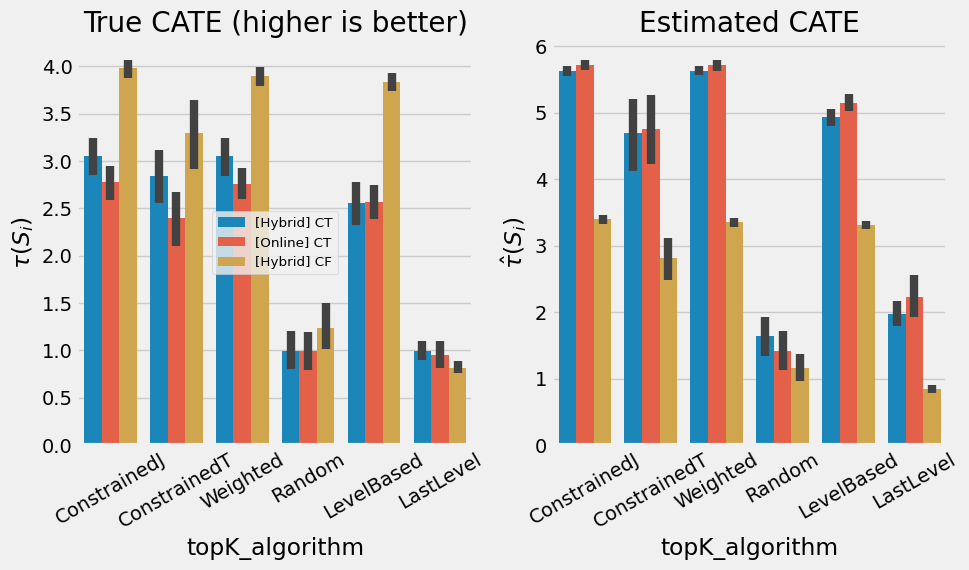

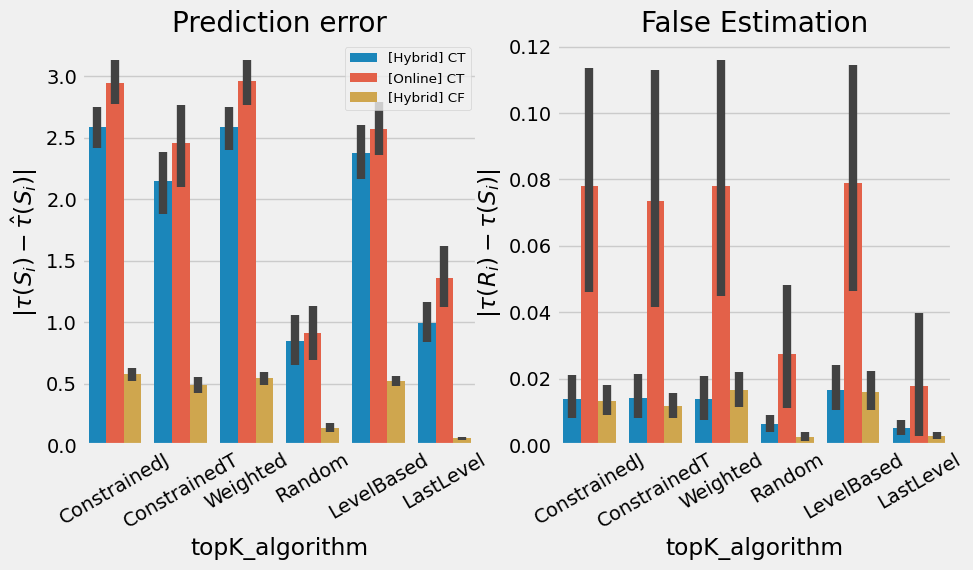

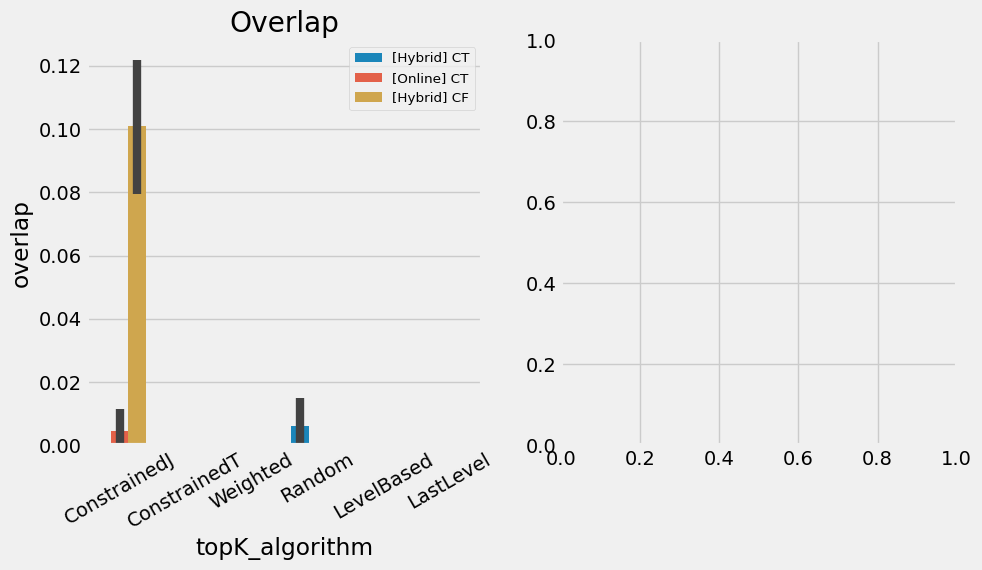

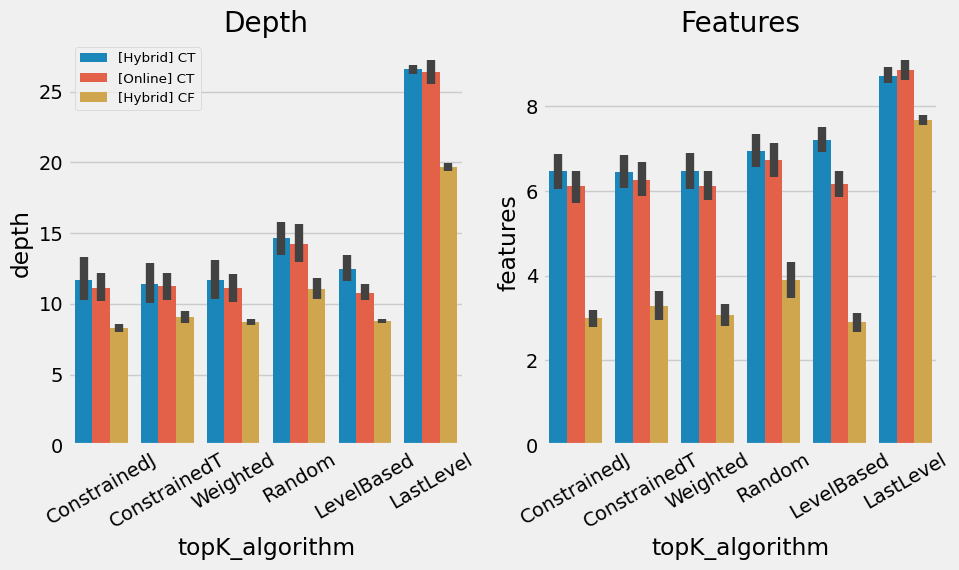

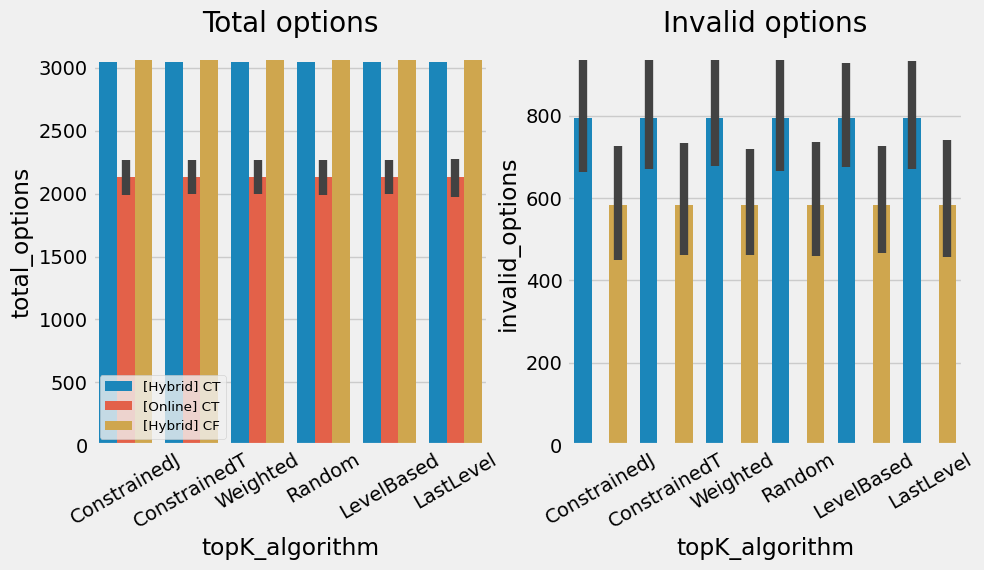

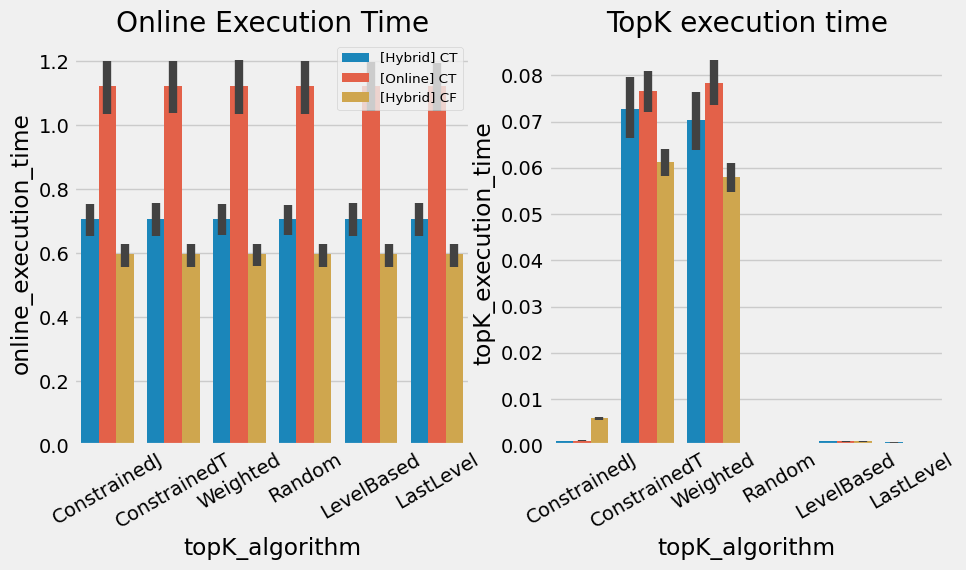

In [2]:
Experiment("topK_algorithm", data_iterations=1, user_iterations=10, algorithms=[CT(), CTP(), CFT()], scanners=all, save_csv=False)